# Task 4: Custom Gradient Descent Optimizers

### Objective
Implement Momentum, RMSprop, and Adam from scratch using PyTorch tensor mathematics.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Fix the random seed so the experiment is repeatable.
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


## 1. Create a Non-Linear Dataset

We create a simple two-moons style dataset using only NumPy.

The dataset is not linearly separable, so a small neural network is needed.

In [2]:
def create_moons(n_samples=500, noise=0.15):
    # Split the samples between the two classes.
    n = n_samples // 2

    # First half-circle
    theta1 = np.linspace(0, np.pi, n)
    x1 = np.column_stack([
        np.cos(theta1),
        np.sin(theta1)
    ])

    # Second half-circle
    theta2 = np.linspace(0, np.pi, n)
    x2 = np.column_stack([
        1 - np.cos(theta2),
        -np.sin(theta2) - 0.5
    ])

    X = np.vstack([x1, x2])

    # Add a little random noise.
    X += np.random.normal(0, noise, X.shape)

    # Class labels.
    y = np.concatenate([
        np.zeros(n),
        np.ones(n)
    ])

    return X, y


X_np, y_np = create_moons()

# Convert NumPy arrays to PyTorch tensors.
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).reshape(-1, 1)

print("Input shape:", X.shape)
print("Target shape:", y.shape)

Input shape: torch.Size([500, 2])
Target shape: torch.Size([500, 1])


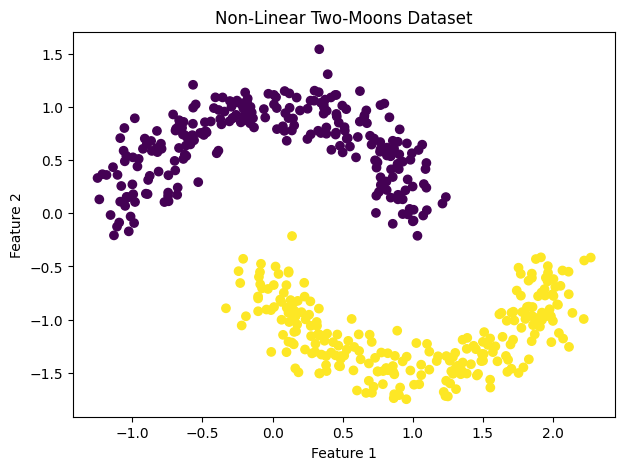

In [3]:
# Display the non-linear dataset.

plt.figure(figsize=(7, 5))

plt.scatter(
    X_np[:, 0],
    X_np[:, 1],
    c=y_np
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Non-Linear Two-Moons Dataset")
plt.show()

## 2. Create a Small Neural Network



In [4]:
def create_model():
    # Small MLP for the non-linear classification problem.
    W1 = torch.randn(2, 16, requires_grad=True) * 0.5
    b1 = torch.zeros(16, requires_grad=True)

    W2 = torch.randn(16, 8, requires_grad=True) * 0.5
    b2 = torch.zeros(8, requires_grad=True)

    W3 = torch.randn(8, 1, requires_grad=True) * 0.5
    b3 = torch.zeros(1, requires_grad=True)

    return [W1, b1, W2, b2, W3, b3]


def forward(X, parameters):
    W1, b1, W2, b2, W3, b3 = parameters

    z1 = X @ W1 + b1
    a1 = torch.relu(z1)

    z2 = a1 @ W2 + b2
    a2 = torch.relu(z2)

    output = a2 @ W3 + b3

    return output


def loss_function(output, target):
    # Binary cross entropy with logits.
    return torch.nn.functional.binary_cross_entropy_with_logits(
        output,
        target
    )

## 3. Custom Momentum Optimizer



In [5]:
def momentum_update(parameters, gradients, velocity, lr=0.05, beta=0.9):
    for i in range(len(parameters)):

        # Exponential moving average of the gradient.
        velocity[i] = beta * velocity[i] + gradients[i]

        # Move the parameter using the velocity.
        parameters[i].sub_(lr * velocity[i])

    return velocity

## 4. Custom RMSprop Optimizer



In [6]:
def rmsprop_update(parameters, gradients, squared_average,
                    lr=0.01, beta=0.9, epsilon=1e-8):

    for i in range(len(parameters)):

        # Keep a moving average of squared gradients.
        squared_average[i] = (
            beta * squared_average[i]
            + (1 - beta) * gradients[i] ** 2
        )

        # Adaptive learning-rate update.
        parameters[i].sub_(
            lr * gradients[i]
            / (torch.sqrt(squared_average[i]) + epsilon)
        )

    return squared_average

## 5. Custom Adam Optimizer

In [7]:
def adam_update(parameters, gradients, first_moment, second_moment,
                 step, lr=0.01, beta1=0.9, beta2=0.999,
                 epsilon=1e-8):

    for i in range(len(parameters)):

        # First raw moment: moving average of gradients.
        first_moment[i] = (
            beta1 * first_moment[i]
            + (1 - beta1) * gradients[i]
        )

        # Second raw moment: moving average of squared gradients.
        second_moment[i] = (
            beta2 * second_moment[i]
            + (1 - beta2) * gradients[i] ** 2
        )

        # Bias correction.
        m_hat = first_moment[i] / (1 - beta1 ** step)
        v_hat = second_moment[i] / (1 - beta2 ** step)

        # Final Adam update.
        parameters[i].sub_(
            lr * m_hat
            / (torch.sqrt(v_hat) + epsilon)
        )

    return first_moment, second_moment

## 6. Training Harness

The same neural network and dataset are trained separately

In [8]:
def train(optimizer_name, epochs=200):

    parameters = create_model()

    # Create optimizer state tensors.
    velocity = [torch.zeros_like(p) for p in parameters]

    squared_average = [torch.zeros_like(p) for p in parameters]

    first_moment = [torch.zeros_like(p) for p in parameters]
    second_moment = [torch.zeros_like(p) for p in parameters]

    losses = []

    for epoch in range(1, epochs + 1):

        # -------------------------
        # Forward pass
        # -------------------------
        output = forward(X, parameters)

        loss = loss_function(output, y)

        losses.append(loss.item())

        # -------------------------
        # Get gradients
        # -------------------------
        gradients = torch.autograd.grad(
            loss,
            parameters
        )

        # -------------------------
        # Custom optimizer update
        # -------------------------
        with torch.no_grad():

            if optimizer_name == "momentum":

                velocity = momentum_update(
                    parameters,
                    gradients,
                    velocity
                )

            elif optimizer_name == "rmsprop":

                squared_average = rmsprop_update(
                    parameters,
                    gradients,
                    squared_average
                )

            elif optimizer_name == "adam":

                first_moment, second_moment = adam_update(
                    parameters,
                    gradients,
                    first_moment,
                    second_moment,
                    epoch
                )

        if epoch % 50 == 0:
            print(
                f"{optimizer_name.upper():8s} | "
                f"Epoch {epoch:3d} | "
                f"Loss: {loss.item():.4f}"
            )

    return losses, parameters

## 7. Train Using All Three Optimizers

In [9]:
results = {}

for optimizer in ["momentum", "rmsprop", "adam"]:

    print("\nTraining with", optimizer)

    losses, parameters = train(
        optimizer,
        epochs=200
    )

    results[optimizer] = losses


Training with momentum
MOMENTUM | Epoch  50 | Loss: 0.0100
MOMENTUM | Epoch 100 | Loss: 0.0056
MOMENTUM | Epoch 150 | Loss: 0.0044
MOMENTUM | Epoch 200 | Loss: 0.0038

Training with rmsprop
RMSPROP  | Epoch  50 | Loss: 0.0074
RMSPROP  | Epoch 100 | Loss: 0.0014
RMSPROP  | Epoch 150 | Loss: 0.0003
RMSPROP  | Epoch 200 | Loss: 0.0001

Training with adam
ADAM     | Epoch  50 | Loss: 0.0124
ADAM     | Epoch 100 | Loss: 0.0037
ADAM     | Epoch 150 | Loss: 0.0022
ADAM     | Epoch 200 | Loss: 0.0015


## 8. Compare Loss Convergence

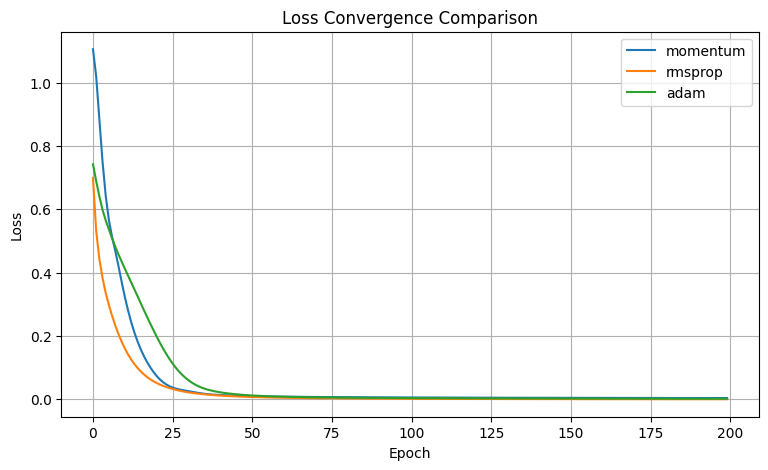

In [10]:
plt.figure(figsize=(9, 5))

for optimizer, losses in results.items():

    plt.plot(
        losses,
        label=optimizer
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Convergence Comparison")
plt.legend()
plt.grid(True)
plt.show()

## 9. Plot Loss on a Log Scale

A logarithmic y-axis makes it easier to compare convergence when the loss becomes small.

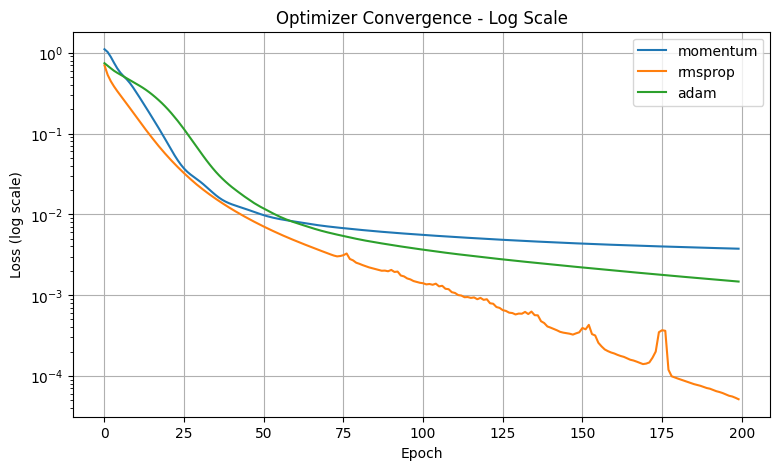

In [11]:
plt.figure(figsize=(9, 5))

for optimizer, losses in results.items():

    plt.plot(
        losses,
        label=optimizer
    )

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Optimizer Convergence - Log Scale")
plt.legend()
plt.grid(True)
plt.show()

## 10. Final Loss Comparison

In [12]:
print("Final loss for each optimizer:")
print("-" * 35)

for optimizer, losses in results.items():

    print(
        f"{optimizer.capitalize():10s}: "
        f"{losses[-1]:.6f}"
    )

Final loss for each optimizer:
-----------------------------------
Momentum  : 0.003756
Rmsprop   : 0.000051
Adam      : 0.001473


## 11. Check Final Classification Accuracy

In [13]:
for optimizer in ["momentum", "rmsprop", "adam"]:

    # Train once more to obtain the final parameters.
    _, parameters = train(
        optimizer,
        epochs=200
    )

    with torch.no_grad():

        logits = forward(X, parameters)

        probabilities = torch.sigmoid(logits)

        predictions = (probabilities >= 0.5).float()

        accuracy = (
            predictions.eq(y).float().mean().item()
        )

    print(
        f"{optimizer.capitalize():10s} accuracy: "
        f"{accuracy * 100:.2f}%"
    )

MOMENTUM | Epoch  50 | Loss: 0.0070
MOMENTUM | Epoch 100 | Loss: 0.0048
MOMENTUM | Epoch 150 | Loss: 0.0039
MOMENTUM | Epoch 200 | Loss: 0.0034
Momentum   accuracy: 100.00%
RMSPROP  | Epoch  50 | Loss: 0.0209
RMSPROP  | Epoch 100 | Loss: 0.0019
RMSPROP  | Epoch 150 | Loss: 0.0003
RMSPROP  | Epoch 200 | Loss: 0.0002
Rmsprop    accuracy: 100.00%
ADAM     | Epoch  50 | Loss: 0.0094
ADAM     | Epoch 100 | Loss: 0.0033
ADAM     | Epoch 150 | Loss: 0.0023
ADAM     | Epoch 200 | Loss: 0.0017
Adam       accuracy: 100.00%
